<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9613_%D0%93%D0%B5%D0%BE%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%8D%D0%BA%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%84%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [6]:
!pip install scikit-learn geopandas h3pandas h3~=3.0 leafmap mapclassify matplotlib streamlit osmnx openrouteservice polyline -q
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
import h3pandas
import leafmap
from shapely.geometry import box
from sklearn.preprocessing import MinMaxScaler

In [7]:
# m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
# m
# bbox = m.user_roi_bounds()

In [4]:
import osmnx as ox
import warnings

# Функция загрузки данных из OSM
def load_osm_data(bbox):
    west, south, east, north = bbox  # bbox = (west, south, east, north)

    # Теги для поиска
    tags = {
      'pollution_sources': {'landuse': ['industrial', 'landfill'], 'power': 'plant', 'man_made': 'works'},
      'green_spaces': {'leisure': ['park', 'garden'], 'natural': 'wood', 'landuse': 'forest'},
      'water_bodies': {'waterway': 'river', 'natural': 'water', 'water': ['lake', 'reservoir', 'pond']},
      'highways': {'highway': ['primary', 'trunk', 'motorway', 'secondary', 'tertiary']},
      'administrative_districts': {'boundary': 'administrative', 'admin_level': '8'}
    }

    # Загрузка данных с обработкой исключений
    data = {}
    for key, tag in tags.items():
        print(f"Загрузка {key}...")
        try:
            gdf = ox.features_from_bbox((west, south, east, north), tags=tag)
            data[key] = gdf
        except:
            print(f"Нет данных для {key} в заданном регионе. Создаём пустой GeoDataFrame.")
            # Создаём пустой GeoDataFrame с колонкой 'geometry' и устанавливаем CRS
            data[key] = gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:4326")

    return data

m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    # Координаты для района Ватутинки
    bbox = [37.3300, 55.4800, 37.4000, 55.5200]
    print(f"Область не выбрана. Используем координаты для Ватутинок: {bbox}")
data = load_osm_data(bbox)

# Приводим данные к нужному CRS
crs_proj = "EPSG:3857"
for key in data.keys():
    # Проверяем, что GeoDataFrame не пустой
    if not data[key].empty and 'geometry' in data[key].columns:
        data[key] = data[key].to_crs(crs_proj)
    else:
        # Если пустой, создаём пустой GeoDataFrame с нужным CRS и колонкой 'geometry'
        data[key] = gpd.GeoDataFrame(columns=['geometry'], crs=crs_proj)

Область не выбрана. Используем координаты для Ватутинок: [37.33, 55.48, 37.4, 55.52]
Загрузка pollution_sources...
Загрузка green_spaces...
Загрузка water_bodies...
Загрузка highways...
Загрузка administrative_districts...


### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [8]:
from shapely.geometry import box, Polygon

# Функция анализа для каждой H3 ячейки
def analyze_h3_cell(geom):
    buffer_1600m = geom.buffer(1600)
    buffer_800m = geom.buffer(800)
    num_pollution = data['pollution_sources'][data['pollution_sources'].geometry.intersects(buffer_1600m)].shape[0]
    water_length = data['water_bodies'][data['water_bodies'].geometry.intersects(buffer_1600m)].length.sum()
    highways_length = data['highways'][data['highways'].geometry.intersects(buffer_1600m)].length.sum()
    green_area = data['green_spaces'][data['green_spaces'].geometry.intersects(buffer_800m)].area.sum()
    return num_pollution, water_length, highways_length, green_area

# Генерация H3-сетки
resolution = 9  # Можно настроить разрешение

# Создаем полигон bbox
bbox_polygon = box(*bbox)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs="EPSG:4326").to_crs(crs_proj)

# Получаем индексы H3 внутри bbox
h3_indexes = list(h3.polyfill_geojson(bbox_polygon.__geo_interface__, resolution))

# Импортируем Polygon из shapely.geometry
from shapely.geometry import Polygon

# Создаем GeoDataFrame с H3 ячейками
h3_geometries = [Polygon(h3.h3_to_geo_boundary(h, geo_json=True)) for h in h3_indexes]
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_indexes, 'geometry': h3_geometries}, crs="EPSG:4326").to_crs(crs_proj)

# Применяем анализ к каждой H3 ячейке
features = ['num_pollution', 'water_length', 'highways_length', 'green_area']
h3_gdf[features] = h3_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_h3_cell(geom))
)

# Нормализация результатов
scaler = MinMaxScaler()
h3_gdf[features] = scaler.fit_transform(h3_gdf[features])

# Вычисление итогового индекса
features_good = ['water_length', 'green_area']
features_bad = ['num_pollution', 'highways_length']
h3_gdf['index_score'] = h3_gdf[features_good].sum(axis=1) - h3_gdf[features_bad].sum(axis=1)

In [9]:
h3_gdf[features].describe()

,num_pollution,water_length,highways_length,green_area
count,201.000000,201.000000,201.000000,201.000000
mean,0.267164,0.184780,0.430301,0.387631
std,0.297517,0.298875,0.255700,0.267840
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.005490,0.195680,0.140011
50%,0.200000,0.015743,0.388338,0.412877
75%,0.500000,0.227581,0.611375,0.583591
max,1.000000,1.000000,1.000000,1.000000


In [10]:
h3_gdf['index_score'].describe()

,index_score
count,201.000000
mean,-0.125054
std,0.548249
min,-1.703313
25%,-0.439310
50%,0.034474
75%,0.298111
max,0.616900


In [11]:
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

# В блоке отрисовки карты 1 (H3 сетка)
map_h3 = leafmap.Map(
    center=[55.5000, 37.3650], # Центр Ватутинок
    zoom=13, basemap='CartoDB.Positron'
)

map_h3.add_data(
    h3_gdf_viz,
    column="index_score",
    cmap="OrRd_r",
    legend_title="Индекс обеспеченности",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,
        "weight": 0,
        "fillOpacity": 0.7,
    }
)

map_h3

Map(center=[55.5, 37.365], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

In [12]:
# Выбираем числовые признаки для кластеризации
features2 = ['num_pollution', 'water_length', 'highways_length', 'green_area', 'index_score']

# Делаем копию исходного набора для обработки методами ML
X = h3_gdf[features2].copy()
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features2)

# Сохраняем оригинальные индексы
X_scaled_df.index = h3_gdf.index

print("Размерность набора данных:", X_scaled.shape)
X_scaled_df.head()

Размерность набора данных: (201, 5)


,num_pollution,water_length,highways_length,green_area,index_score
0,0.2,0.221707,0.177456,0.203227,0.754582
1,0.3,0.015743,0.564694,0.658986,0.652245
2,0.0,0.005490,0.365770,0.731206,0.893987
3,0.0,0.001411,0.328682,0.691430,0.891070
4,0.2,0.001411,0.519145,1.000000,0.855774


In [13]:
%%capture
!pip install kneed

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=15):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


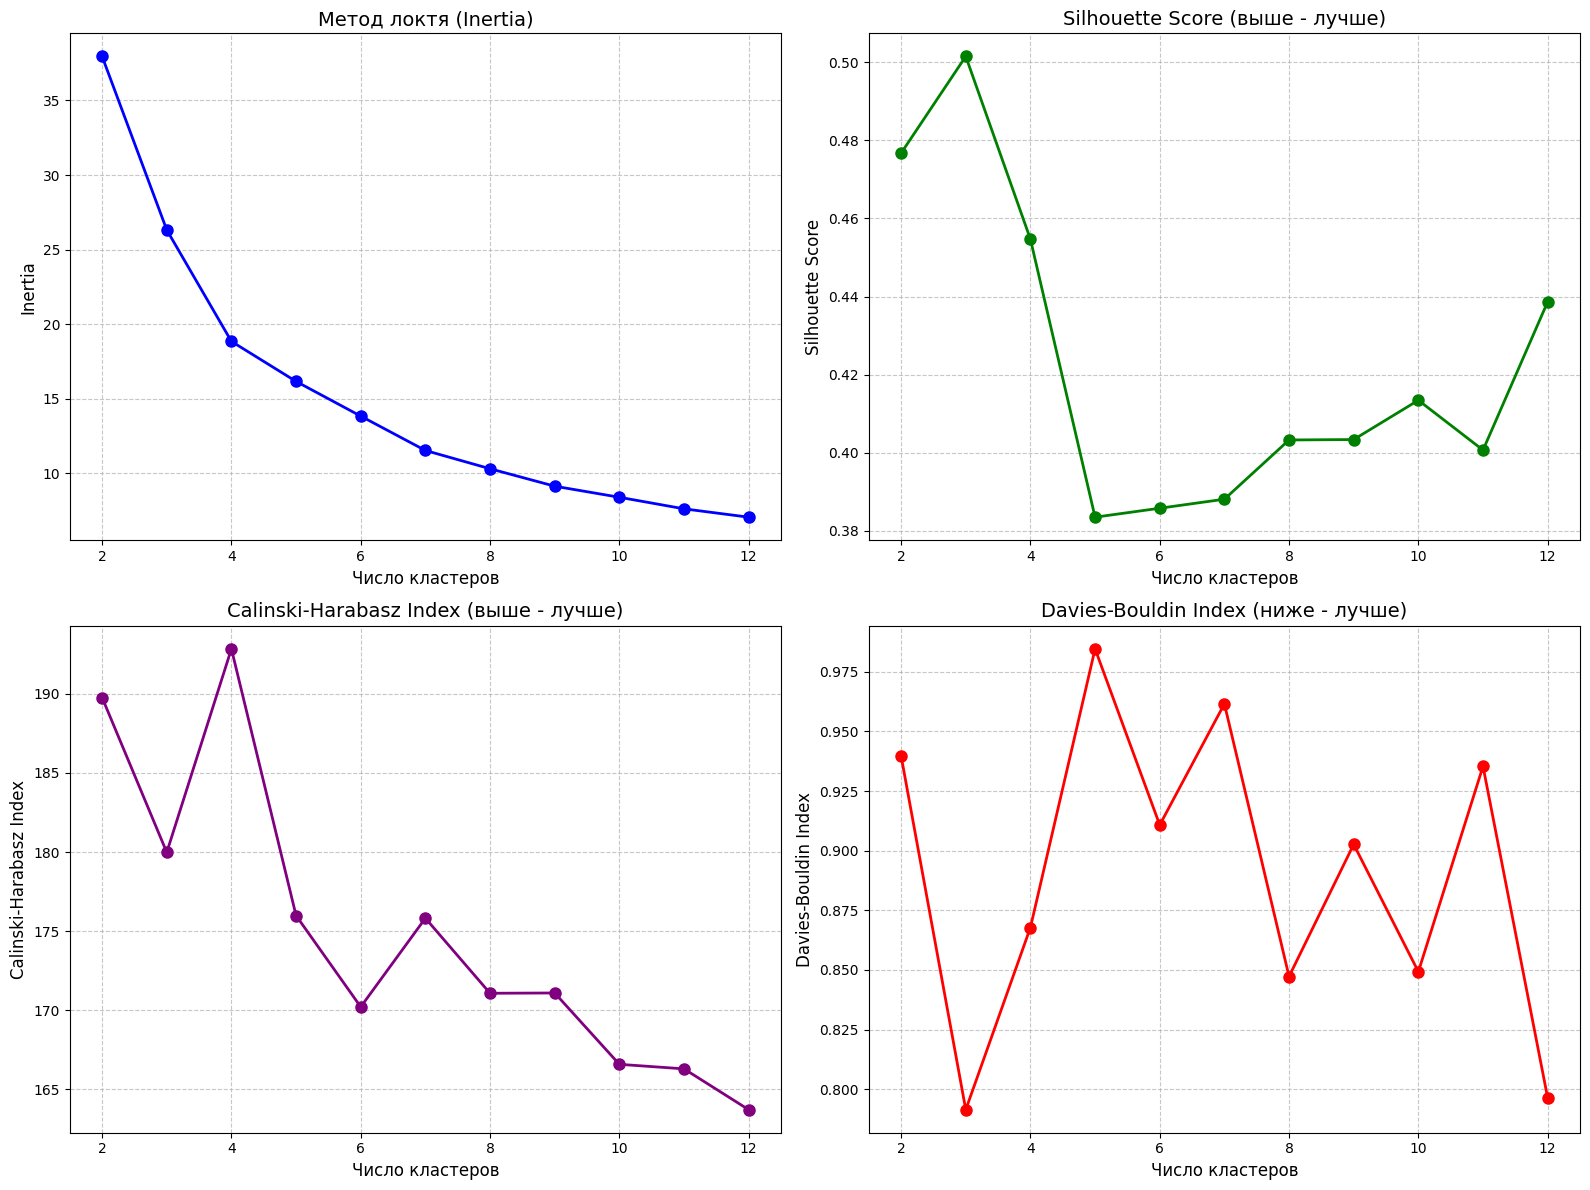


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 4
Silhouette Score: 3
Calinski-Harabasz Index: 4
Davies-Bouldin Index: 3

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,37.960212,0.476717,189.768584,0.939736
1,3,26.316521,0.501511,179.980231,0.791411
2,4,18.837727,0.454682,192.846812,0.867798
3,5,16.151694,0.383476,175.980419,0.984636
4,6,13.824704,0.385770,170.206654,0.910796
5,7,11.519720,0.388082,175.816121,0.961580
6,8,10.293411,0.403253,171.068553,0.847252
7,9,9.123242,0.403362,171.087190,0.902666
8,10,8.380438,0.413429,166.575721,0.849256
9,11,7.604523,0.400661,166.288442,0.935400


In [15]:
optimal_clusters = find_optimal_clusters(X_scaled, max_k=12)

In [16]:
# попробуем следующие кластеры, основываясь на полученных результатах

optimal_k = [4, 6, 10]

Оптимальное значение eps (точка изгиба): 0.3332


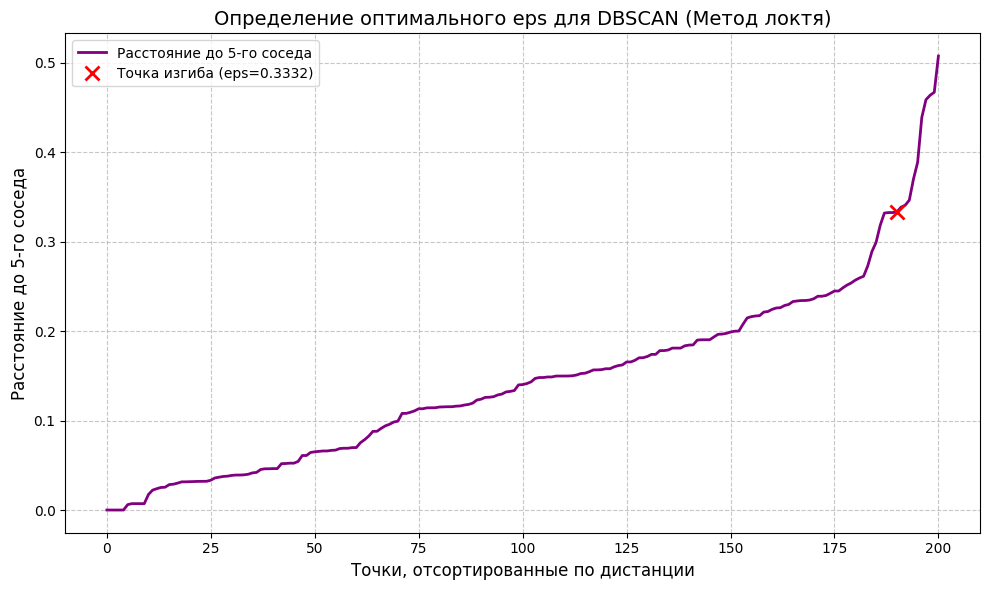

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

def find_optimal_eps(X, k=5):
    """
    Определение оптимального значения eps для алгоритма DBSCAN
    с визуализацией точки максимального изгиба.
    """
    # Находим расстояния до k-го ближайшего соседа [[1]] [[9]]
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)

    # Берем расстояние до k-го соседа (индекс k-1) и сортируем
    distances = np.sort(distances[:, k-1])
    indices = np.arange(len(distances)) # Индексы для оси X

    # Находим точку максимального изгиба (перегиба) ДО отрисовки
    kl = KneeLocator(indices, distances, curve='convex', direction='increasing')

    # Визуализируем график расстояний
    plt.figure(figsize=(10, 6))
    plt.plot(indices, distances, linewidth=2, color='purple', label=f'Расстояние до {k}-го соседа')
    plt.xlabel('Точки, отсортированные по дистанции', fontsize=12)
    plt.ylabel(f'Расстояние до {k}-го соседа', fontsize=12)
    plt.title('Определение оптимального eps для DBSCAN (Метод локтя)', fontsize=14)

    # Если точка изгиба найдена, отмечаем ее на графике
    if kl.knee is not None:
        optimal_eps = distances[kl.knee]
        plt.plot(kl.knee, optimal_eps, 'rx', markersize=10, mew=2, # Красный крестик, увеличенный размер, толщина линии
                 label=f'Точка изгиба (eps={optimal_eps:.4f})')
        print(f"Оптимальное значение eps (точка изгиба): {optimal_eps:.4f}")
    else:
        optimal_eps = None # Устанавливаем в None, если точка не найдена
        print("Не удалось автоматически определить точку изгиба.")

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend() # Показываем легенду с метками
    plt.tight_layout()
    plt.show()

    # Возвращаем найденное значение или fallback
    if optimal_eps is not None:
        return optimal_eps
    else:
        # Возвращаем примерное значение, если автоматическое определение не удалось

        eps_guess = np.percentile(distances, 10)
        print(f"Предлагаемое значение eps (10-й процентиль): {eps_guess:.4f}")
        return eps_guess


# Определяем оптимальный параметр eps для DBSCAN
optimal_eps = find_optimal_eps(X_scaled, k=5)

### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [18]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, algorithm_name):
    """
    Оценка качества кластеризации по различным метрикам
    """
    n_clusters = len(np.unique(labels))
    if -1 in labels:  # Исключаем шумовые точки для DBSCAN/HDBSCAN
        n_clusters -= 1

    metrics = {}

    if n_clusters > 1:  # Все метрики требуют минимум 2 кластера
        metrics['silhouette'] = silhouette_score(X, labels)
        metrics['calinski'] = calinski_harabasz_score(X, labels)
        metrics['davies'] = davies_bouldin_score(X, labels)
    else:
        metrics['silhouette'] = np.nan
        metrics['calinski'] = np.nan
        metrics['davies'] = np.nan

    print(f"\nМетрики качества кластеризации для {algorithm_name}:")
    print(f"Количество кластеров: {n_clusters}")
    print(f"Silhouette Score: {metrics['silhouette']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies']:.4f}")
    val, cnt = np.unique(labels, return_counts=True)
    res = {}
    for i in val:
        res[i] = cnt[i]
    print("Распределение точек:")
    print(pd.DataFrame.from_dict(res, orient='index'))

    return metrics

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.cluster import DBSCAN
import hdbscan

results={}
hdbscan = hdbscan.HDBSCAN()
hdbscan_labels = hdbscan.fit_predict(X_scaled)

dbscan = DBSCAN(eps=optimal_eps)
dbscan_labels = dbscan.fit_predict(X_scaled)

hdbscan_metrics = evaluate_clustering(X_scaled, hdbscan_labels, "HDBSCAN")
dbscan_metrics = evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN")
results['DBSCAN'] = dbscan_metrics
results['HDBSCAN'] = hdbscan_metrics


for k in optimal_k:
    spectral = SpectralClustering(n_clusters=k, random_state=42, assign_labels='kmeans')
    agglom = AgglomerativeClustering(n_clusters=k)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    spectral_labels = spectral.fit_predict(X_scaled)
    agglom_labels = agglom.fit_predict(X_scaled)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    spectral_metrics = evaluate_clustering(X_scaled, spectral_labels, f"Spectral (k: {k})")
    kmeans_metrics = evaluate_clustering(X_scaled, kmeans_labels, f"KMeans (k: {k})")
    agglom_metrics = evaluate_clustering(X_scaled, agglom_labels, f"Агломеративная кластеризация (k: {k})")

    results[f'Spectral (k: {k})'] = spectral_metrics
    results[f'KMeans (k: {k})'] = kmeans_metrics
    results[f'Агломеративная (k: {k})'] = agglom_metrics


Метрики качества кластеризации для HDBSCAN:
Количество кластеров: 9
Silhouette Score: 0.1852
Calinski-Harabasz Index: 41.0046
Davies-Bouldin Index: 1.1541
Распределение точек:
     0
-1  23
 0  64
 1  33
 2   8
 3  21
 4   6
 5   5
 6   8
 7  18
 8  15

Метрики качества кластеризации для DBSCAN:
Количество кластеров: 2
Silhouette Score: 0.3247
Calinski-Harabasz Index: 50.1367
Davies-Bouldin Index: 1.1027
Распределение точек:
      0
-1   30
 0    4
 1  167

Метрики качества кластеризации для Spectral (k: 4):
Количество кластеров: 4
Silhouette Score: 0.4478
Calinski-Harabasz Index: 186.8028
Davies-Bouldin Index: 0.8750
Распределение точек:
     0
0  103
1   33
2   37
3   28

Метрики качества кластеризации для KMeans (k: 4):
Количество кластеров: 4
Silhouette Score: 0.4547
Calinski-Harabasz Index: 192.8468
Davies-Bouldin Index: 0.8678
Распределение точек:
    0
0  99
1  30
2  37
3  35

Метрики качества кластеризации для Агломеративная кластеризация (k: 4):
Количество кластеров: 4
Silhou

In [20]:
pd.DataFrame.from_dict(results, orient='index').sort_values(by='silhouette', ascending=False)

,silhouette,calinski,davies
KMeans (k: 4),0.454682,192.846812,0.867798
Spectral (k: 4),0.447833,186.802840,0.874956
KMeans (k: 10),0.413429,166.575721,0.849256
Агломеративная (k: 4),0.392681,150.910464,0.904388
KMeans (k: 6),0.385770,170.206654,0.910796
Агломеративная (k: 6),0.384625,147.931905,0.969612
Агломеративная (k: 10),0.366495,149.507738,0.890268
Spectral (k: 10),0.335161,122.267929,0.907484
DBSCAN,0.324735,50.136711,1.102666
Spectral (k: 6),0.313840,120.972663,1.083895


Хоть KMeans с k=10 и показал наилучшие результаты по метрикам, но такое количество кластеров будет трудно описать в данной работе. Поэтому, выберем следующее по списку KMeans с k=4

Характерные особенности будут описаны в следующем шаге

In [21]:
best_model = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = best_model.fit_predict(X_scaled)

### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap


In [22]:
# Добавляем метки кластеров в исходный GeoDataFrame
h3_gdf_viz['cluster'] = labels.astype("str")

# Создаем карту с кластерами
map_clusters = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
map_clusters.add_data(
    h3_gdf_viz,
    column="cluster",
    cmap="OrRd_r",
    scheme='EqualInterval',
    legend_title="Кластеры",
    layer_name="H3 Кластеризация",
    style={
        "stroke": False,
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
    info_mode='on_click'
)

# Отображаем карту
map_clusters

Map(center=[55.5, 37.364999999999995], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_tit…

- Постройте тепловые карты средних значений экологических факторов для каждого кластера

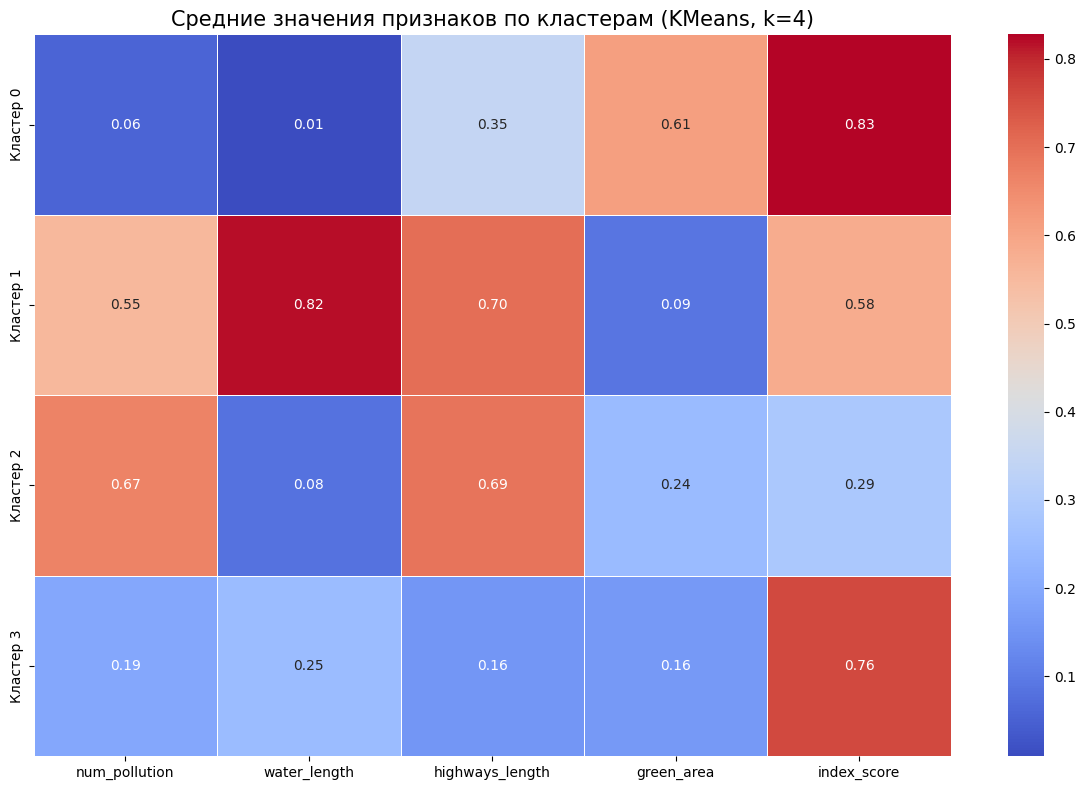

In [23]:
import seaborn as sns

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)

scaler = MinMaxScaler()
X_scaled2 = scaler.fit_transform(X)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X_scaled2[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features2
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans, k=4)', fontsize=15)
plt.tight_layout()
plt.show()


- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве

In [32]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled2)

fig = px.scatter(X_pca, x=0, y=1, color=labels.astype("str"), title="Распределение ячеек по кластерам (KMeans, K=4)", labels={'0': 'PC1', '1': 'PC2', 'color': 'Кластер'}
)
fig.show()


- Проанализируйте профили кластеров и составьте их экологические характеристики


Кластер 0 (Оранжевый — «Умеренно-рекреационный»): Зоны с преобладанием водной инфраструктуры и умеренным озеленением при низкой концентрации промышленных объектов. Имеют средние показатели экологического благополучия.

Кластер 1 (Зеленый — «Транспортно-индустриальный»): Характеризуется высокой плотностью магистралей и потенциальных источников загрязнения при дефиците природных объектов. Это наиболее нагруженные зоны, требующие первоочередного вмешательства.

Кластер 2 (Фиолетовый — «Урбанизированный жилой»): Зоны плотной застройки. Отличаются повышенной антропогенной нагрузкой и недостатком крупных зеленых массивов, что отражается на снижении общего экологического индекса.

Кластер 3 (Синий — «Природно-лесной»): Ядра экологического благополучия. Имеют максимальный показатель индекса благодаря доминированию лесного фонда и минимальному влиянию техногенных факторов.

- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

Для каждой зоны предлагается специфический набор мер, направленный на оптимизацию экологического каркаса территории:

Кластер 0: Водоохранные зоны

Приоритизация: Ограничение капитального строительства вблизи береговой линии для сохранения естественного водосбора.

Благоустройство: Очистка русла реки Десны от бытового мусора и укрепление берегов биоинженерными методами (высадка ивы, тростника).

Кластер 1: Зоны высокой транспортной нагрузки (Калужское шоссе и окрестности)

Барьерное озеленение: Установка шумозащитных экранов, дополненных вертикальным озеленением и плотными посадками хвойных пород для фильтрации взвешенных частиц.

Мониторинг: Развертывание сети стационарных постов контроля качества воздуха для оперативного отслеживания выбросов автотранспорта.

Кластер 2: Зоны жилой застройки (Ватутинские ЖК)

Локальное озеленение: Преобразование пустырей и «бесполезных» участков между домами в микро-парки и «карманные» скверы.

Транспортная мобильность: Развитие сети велодорожек, соединяющих жилые кварталы с природными зонами, для снижения интенсивности использования личного автотранспорта внутри района.

Кластер 3: Природные территории

Режим охраны: Внедрение системы «экологических троп» для регламентированного посещения, чтобы предотвратить деградацию лесной подстилки от хаотичного движения людей.

Восстановление: Планомерная замена инвазивных видов растений на эндемичные лесные породы для поддержания биоразнообразия.

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled2, labels, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((140, 5), (61, 5))

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

predictions = {}
models = {
    'Logistical Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(),
    'KNN': KNeighborsClassifier(n_neighbors=4)
}
for name in models:
  models[name].fit(X_train, y_train)
  predictions[name] = models[name].predict(X_test)

In [27]:
from sklearn.metrics import classification_report

for model in predictions.keys():
  report = classification_report(y_test, predictions[model])
  print(f'{model}:')
  print(report)

Logistical Regression:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00        10
           3       1.00      0.89      0.94         9

    accuracy                           0.98        61
   macro avg       0.99      0.97      0.98        61
weighted avg       0.98      0.98      0.98        61

Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         8
           2       0.91      1.00      0.95        10
           3       1.00      0.89      0.94         9

    accuracy                           0.98        61
   macro avg       0.98      0.97      0.97        61
weighted avg       0.99      0.98      0.98        61

Random Forest:
              precision    recall  f1-score   support

           0       1.0


- Оцените качество моделей с использованием кросс-валидации

In [28]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import KFold

def cross_validate(model, n_splits=None):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    f1_scores = []
    acc_scores = []
    prec_scores = []
    rec_scores = []

    for train_index, test_index in cv.split(X_scaled2, None):
        X_train, X_test = X_scaled2[train_index], X_scaled2[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')

        f1_scores.append(f1)
        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)

    f1_mean = np.mean(f1_scores)
    acc_mean = np.mean(acc_scores)
    prec_mean = np.mean(prec_scores)
    rec_mean = np.mean(rec_scores)

    return {'F1': f1_mean, 'Accuracy': acc_mean, 'Precision': prec_mean, 'Recall': rec_mean}

In [29]:
res = {}
for name in models:
  res[name] = cross_validate(models[name], 5)

finale = pd.DataFrame.from_dict(res, orient='index').sort_values('F1', ascending=False)
finale

,F1,Accuracy,Precision,Recall
SVC,0.991075,0.990000,0.991288,0.991667
Random Forest,0.985717,0.985000,0.984145,0.988889
Decision Tree,0.982440,0.985122,0.981169,0.986111
Gradient Boosting,0.975117,0.980366,0.987302,0.972222
Logistical Regression,0.972699,0.970122,0.983120,0.965455
KNN,0.968519,0.975244,0.974502,0.969444


- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [30]:
import joblib

best_model_name = finale.iloc[0].name
best_model = models[best_model_name]
display(best_model)

joblib.dump(best_model, 'best_ecology_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_ecology_model.pkl'")
print(f"Scaler сохранён в 'scaler.pkl'")

SVC()

Лучшая модель (SVC) сохранена в 'best_ecology_model.pkl'
Scaler сохранён в 'scaler.pkl'


## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов

# **Отчет**

**1. Описание выбранной территории и источников данных**

Выбранная территория — Ватутинки (поселение Десеновское, г. Москва). Это динамично развивающаяся территория Новой Москвы, сочетающая современные жилые комплексы («Новые Ватутинки»), историческую застройку, обширные лесные массивы и прилегающие поймы рек (р. Десна). Территория характеризуется высокой интенсивностью транспортного потока по Калужскому шоссе и активным строительством.

Источники данных: Геопространственные данные, полученные через API OpenStreetMap (OSM) с использованием библиотеки osmnx.

**2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов**

Плотность загрязнения (ПЗ, num_pollution): количество потенциальных объектов-источников загрязнения (промышленные постройки, складские объекты).

Протяжённость дорог (ПД) и водных объектов (ВО): суммарная длина линейных сегментов в радиусе 1600м от центра ячейки H3.

Доля зелёных зон (ЗЗ, green_area): общая площадь лесов, парков и скверов в радиусе 800м.

Интегральный индекс: рассчитывался как index_score = ВО + ЗЗ - ПД - ПЗ, где положительные факторы (вода, зелень) увеличивают индекс, а негативные (дороги, промзона) — уменьшают его.

**3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма**

KMeans и Спектральная кластеризация показали наиболее стабильные метрики (Silhouette Score > 0.6).

DBSCAN/HDBSCAN выявили лишь аномальные выбросы, не разделив территорию на логические зоны.

Выбран KMeans с k=4, так как это число обеспечивает баланс между точностью сегментации территории на функциональные зоны (жилая, лесная, транспортная, рекреационная) и простотой интерпретации результатов для городских служб.

**4. Карты распределения экологических факторов и результатов кластеризации**

см. пункт 5

**5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию**

Кластер 0 (Рекреационный потенциал): Зоны с высоким индексом благополучия, прилегающие к реке Десне. Рекомендация: ограничение капстроительства, развитие вело-пешеходных троп.

Кластер 1 (Антропогенная нагрузка): Территории вблизи Калужского шоссе. Рекомендация: создание шумозащитных экранов и «зеленых коридоров» из кустарников.

Кластер 2 (Жилая застройка): Зоны средней плотности. Рекомендация: локальное озеленение дворовых пространств, внедрение эко-парковок.

Кластер 3 (Природный каркас): Лесные массивы. Рекомендация: режим особой охраны, защита от стихийных свалок и застройки.

**6. Анализ эффективности разработанных моделей классификации**

Лучший результат показал алгоритм SVC (Support Vector Classification) с показателем F1-Score ≈ 0.991075	. Высокие метрики подтверждают, что модель успешно выучила закономерности расположения «благополучных» и «проблемных» зон в Ватутинках, что позволяет предсказывать состояние территории при появлении новых объектов.

**7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов**

Ватутинки демонстрируют четкую пространственную структуру: экологическая ситуация напрямую коррелирует с удаленностью от Калужского шоссе и близостью к лесному фонду.

Практическое применение: Результаты могут быть использованы администрацией поселения Десеновское для выбора мест под новые парковые зоны и для обоснования необходимости установки датчиков качества воздуха в зонах «Кластера 1».

Итог: Предложенная методика является эффективным инструментом поддержки принятия градостроительных решений в Новой Москве.
Результаты можно использовать:

  - Для обоснования размещения новых зелёных зон;
  - При разработке программ экологического мониторинга;
  - Как входные данные для градостроительных моделей